In [2]:
import warnings
warnings.filterwarnings("ignore")

import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np

AUTOTUNE = tf.data.AUTOTUNE
tf.random.set_seed(42)
np.random.seed(42)

# =========================
# 0) 설정 (꽃 분류용)
# =========================
IMG_SIZE = 224
BATCH_SIZE = 32
SHUFFLE_BUFFER_SIZE = 2000
NUM_CLASSES = 5  # 꽃 종류 5개

USE_MIXUP = True
USE_CUTMIX = True
MIX_ALPHA = 0.2
LABEL_SMOOTHING = 0.05
DROPOUT = 0.3
BACKBONE = "EfficientNetV2B0"

# =========================
# 1) 데이터 로드 (tf_flowers)
# =========================
print("1. 데이터 로드 중... (tf_flowers)")
(raw_train, raw_validation, raw_test), metadata = tfds.load(
    name='tf_flowers',
    split=['train[:80%]', 'train[80%:90%]', 'train[90%:]'],
    with_info=True,
    as_supervised=True,
)

# =========================
# 2) 전처리/증강
# =========================
if BACKBONE.startswith("EfficientNetV2"):
    preprocess = tf.keras.applications.efficientnet_v2.preprocess_input
    BackboneClass = getattr(tf.keras.applications, BACKBONE)
elif BACKBONE == "VGG16":
    preprocess = tf.keras.applications.vgg16.preprocess_input
    BackboneClass = tf.keras.applications.VGG16
else:
    raise ValueError("지원하지 않는 BACKBONE 입니다.")

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomContrast(0.10),
    tf.keras.layers.RandomTranslation(0.1, 0.1),
], name="aug")

def format_example(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32)
    image = preprocess(image)
    label = tf.one_hot(label, NUM_CLASSES)
    return image, label

train = raw_train.map(format_example, num_parallel_calls=AUTOTUNE)
validation = raw_validation.map(format_example, num_parallel_calls=AUTOTUNE)
test = raw_test.map(format_example, num_parallel_calls=AUTOTUNE)

train = train.shuffle(SHUFFLE_BUFFER_SIZE, reshuffle_each_iteration=True).batch(BATCH_SIZE)
validation = validation.batch(BATCH_SIZE)
test = test.batch(BATCH_SIZE)

train = train.cache().prefetch(AUTOTUNE)
validation = validation.cache().prefetch(AUTOTUNE)
test = test.cache().prefetch(AUTOTUNE)

# =========================
# 3) MixUp / CutMix 함수 정의
# =========================
def sample_beta_distribution(size, concentration_0=0.2, concentration_1=0.2):
    gamma_1 = tf.random.gamma(shape=[size], alpha=concentration_1)
    gamma_2 = tf.random.gamma(shape=[size], alpha=concentration_0)
    return gamma_1 / (gamma_1 + gamma_2)

def mixup(batch_x, batch_y, alpha=MIX_ALPHA):
    bs = tf.shape(batch_x)[0]
    lam = sample_beta_distribution(bs, alpha, alpha)
    lam_x = tf.reshape(lam, (bs, 1, 1, 1))
    lam_y = tf.reshape(lam, (bs, 1))
    
    idx = tf.random.shuffle(tf.range(bs))
    x2 = tf.gather(batch_x, idx)
    y2 = tf.gather(batch_y, idx)
    
    x = batch_x * lam_x + x2 * (1 - lam_x)
    y = batch_y * lam_y + y2 * (1 - lam_y)
    return x, y

def cutmix(batch_x, batch_y, alpha=MIX_ALPHA):
    bs = tf.shape(batch_x)[0]
    lam = sample_beta_distribution(bs, alpha, alpha)
    
    idx = tf.random.shuffle(tf.range(bs))
    x2 = tf.gather(batch_x, idx)
    y2 = tf.gather(batch_y, idx)
    
    h = tf.shape(batch_x)[1]
    w = tf.shape(batch_x)[2]
    
    cut_rat = tf.sqrt(1. - lam)
    cut_w = tf.cast(tf.cast(w, tf.float32) * cut_rat, tf.int32)
    cut_h = tf.cast(tf.cast(h, tf.float32) * cut_rat, tf.int32)
    
    cx = tf.random.uniform((bs,), 0, w, dtype=tf.int32)
    cy = tf.random.uniform((bs,), 0, h, dtype=tf.int32)
    
    x1 = tf.clip_by_value(cx - cut_w // 2, 0, w)
    x2b = tf.clip_by_value(cx + cut_w // 2, 0, w)
    y1 = tf.clip_by_value(cy - cut_h // 2, 0, h)
    y2b = tf.clip_by_value(cy + cut_h // 2, 0, h)
    
    def cutmix_single(args):
        img, img2, y, yb, x1_, x2_, y1_, y2_, lam_ = args
        paddings = [[y1_, h - y2_], [x1_, w - x2_], [0, 0]]
        mask = tf.pad(tf.ones((y2_ - y1_, x2_ - x1_, 3)), paddings)
        img = img * (1 - mask) + img2 * mask
        
        box_area = tf.cast((x2_ - x1_) * (y2_ - y1_), tf.float32)
        lam_eff = 1. - box_area / tf.cast(h * w, tf.float32)
        y = y * lam_eff + yb * (1 - lam_eff)
        return img, y

    elems = (batch_x, x2, batch_y, y2, x1, x2b, y1, y2b, lam)
    out_imgs, out_lbls = tf.map_fn(cutmix_single, elems, fn_output_signature=(tf.float32, tf.float32))
    return out_imgs, out_lbls

def augment_and_mix(x, y):
    x = data_augmentation(x, training=True)
    if USE_MIXUP and USE_CUTMIX:
        p = tf.random.uniform(())
        x, y = tf.cond(p < 0.5, lambda: mixup(x, y), lambda: cutmix(x, y))
    elif USE_MIXUP:
        x, y = mixup(x, y)
    elif USE_CUTMIX:
        x, y = cutmix(x, y)
    return x, y

train_mixed = train.map(augment_and_mix, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

# =========================
# 4) 모델 정의 (에러 수정됨)
# =========================
IMG_SHAPE = (IMG_SIZE, IMG_SIZE, 3)

base_model = BackboneClass(input_shape=IMG_SHAPE, include_top=False, weights="imagenet")
base_model.trainable = False

inputs = tf.keras.Input(shape=IMG_SHAPE)
x = inputs
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(DROPOUT)(x)
outputs = tf.keras.layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-5),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING),
    metrics=['accuracy']
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=3, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2)
]

# =========================
# 5) 학습 실행
# =========================
print("\n===== 1단계: Head Training =====")
history1 = model.fit(train_mixed, epochs=8, validation_data=validation, callbacks=callbacks)

print("\n===== 2단계: Fine-Tuning =====")
base_model.trainable = True
fine_tune_at = int(len(base_model.layers) * 0.8) # 상위 20%만 학습
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-4, weight_decay=1e-5),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING),
    metrics=['accuracy']
)

history2 = model.fit(
    train_mixed,
    epochs=20,
    initial_epoch=history1.epoch[-1] + 1,
    validation_data=validation,
    callbacks=callbacks
)

# =========================
# 6) 최종 결과 출력
# =========================
print("\n===== 최종 테스트 =====")
loss, acc = model.evaluate(test)
print(f"Test Accuracy: {acc*100:.2f}%")

1. 데이터 로드 중... (tf_flowers)


Dl Completed...:   0%|          | 0/5 [00:00<?, ? file/s]

Dataset tf_flowers downloaded and prepared to C:\Users\steve\tensorflow_datasets\tf_flowers\3.0.1. Subsequent calls will reuse this data.

===== 1단계: Head Training =====
Epoch 1/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 32s 261ms/step - accuracy: 0.4687 - loss: 1.3933 - val_accuracy: 0.8202 - val_loss: 0.6886 - learning_rate: 0.0010
Epoch 2/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 24s 250ms/step - accuracy: 0.7210 - loss: 0.9834 - val_accuracy: 0.8610 - val_loss: 0.5863 - learning_rate: 0.0010
Epoch 3/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 23s 243ms/step - accuracy: 0.7307 - loss: 0.9540 - val_accuracy: 0.8856 - val_loss: 0.5468 - learning_rate: 0.0010
Epoch 4/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 23s 245ms/step - accuracy: 0.7825 - loss: 0.8899 - val_accuracy: 0.9046 - val_loss: 0.5247 - learning_rate: 0.0010
Epoch 5/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 22s 228ms/step - accuracy: 0.7684 - loss: 0.9039 - val_accuracy: 0.9074 - val_loss: 0.5106 - learning_rate: 0.0010
Epoch 6/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 23s 245ms/step - accuracy: 0.7782

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


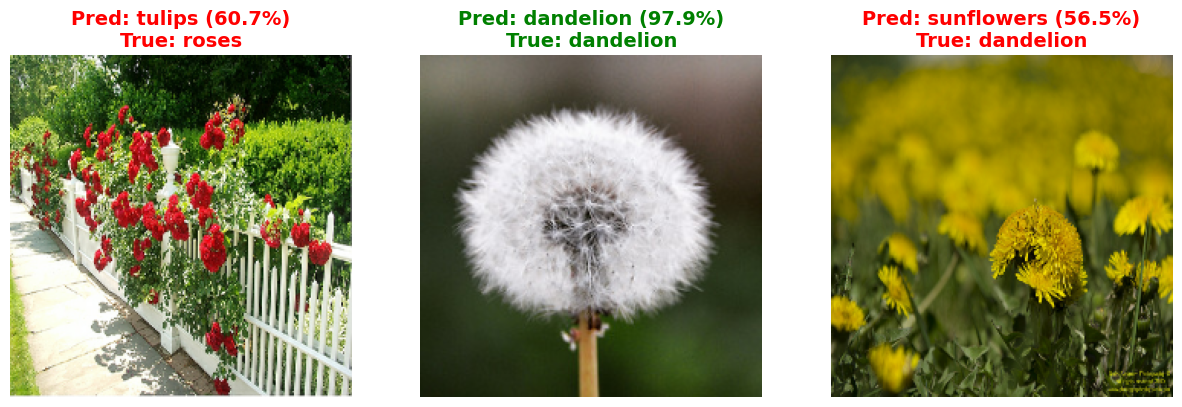

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

# 1. 테스트 데이터에서 샘플 3개 가져오기
# (데이터셋 로드할 때 받은 metadata를 이용해서 꽃 이름을 가져옵니다)
get_label_name = metadata.features['label'].int2str

plt.figure(figsize=(15, 5))

for i, (image, label) in enumerate(test.take(1)): # 배치 하나 가져옴
    # 배치에서 앞의 3장만 뽑아서 그림
    predictions = model.predict(image)
    
    for j in range(3):
        ax = plt.subplot(1, 3, j + 1)
        
        # 이미지 출력 (224x224)
        # 전처리된 이미지는 값이 -1~1 또는 0~1일 수 있어서 보기 좋게 변환
        img_display = image[j].numpy()
        # EfficientNet 전처리는 보통 0~255가 아닐 수 있어서 범위 보정
        img_display = (img_display - img_display.min()) / (img_display.max() - img_display.min())
        
        plt.imshow(img_display)
        
        # 예측 (Softmax니까 가장 높은 확률의 인덱스 찾기)
        pred_idx = np.argmax(predictions[j])
        pred_prob = np.max(predictions[j]) * 100
        pred_label = get_label_name(pred_idx)
        
        # 정답
        # 원-핫 인코딩 되어있으면 argmax, 아니면 그대로
        if len(label[j].shape) > 0 and label[j].shape[0] > 1:
             true_idx = np.argmax(label[j])
        else:
             true_idx = int(label[j])
             
        true_label = get_label_name(true_idx)
        
        # 색상: 맞으면 초록, 틀리면 빨강
        col = 'green' if pred_idx == true_idx else 'red'
        
        plt.title(f"Pred: {pred_label} ({pred_prob:.1f}%)\nTrue: {true_label}", 
                  color=col, fontsize=14, fontweight='bold')
        plt.axis("off")

plt.show()